# Spooky Author Identification — the three methodologies compared

| # | Methodology | Representation | Learner |
|---|---|---|---|
| 1 | NB-weighted n-gram logistic regression | word 1–2-grams + character 1–5-grams, TF-IDF, Naive-Bayes log-count-ratio scaling | one-vs-rest logistic regression |
| 2 | Stylometry + latent topics | 221 hand-built style statistics + 100 SVD topics | LightGBM |
| 3 | Character + word CNN | learned embeddings of characters and words | convolutional network (from scratch) |

All three were trained on **the same five stratified folds** (`results/folds.csv`), without pre-trained weights, and their probabilities were temperature-scaled with a
temperature fitted on the *other* folds' out-of-fold predictions. Scores below are **out-of-fold**: every sentence is scored by a model that never saw it. The metric is multiclass log loss
(lower is better; predicting the class frequencies gives 1.0875). No blend or stack is built: this notebook compares the three as they are.

In [1]:
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.calibration import calibration_curve
import spooky_common as S
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
AU = S.AUTHORS; M = {"nblr": "1. NB-weighted n-gram LR", "style_gbdt": "2. Stylometry + topics (LightGBM)", "cnn": "3. Char + word CNN"}; COL = {"nblr": "#4C72B0", "style_gbdt": "#55A868", "cnn": "#C44E52"}
train, test, folds, y = S.load(); P, T, E = {}, {}, {}
for k in M: P[k], T[k], meta = S.load_method(k); E[k] = S.evaluate(y, P[k], folds)
prior = np.tile(np.bincount(y) / len(y), (len(y), 1)); ev_prior = S.evaluate(y, prior, folds, 200)
tab = pd.DataFrame({M[k]: dict(log_loss=e["log_loss"], ci_low=e["log_loss_ci95"][0], ci_high=e["log_loss_ci95"][1], accuracy=e["accuracy"], macro_f1=e["macro_f1"], **{f"F1 {a}": e["f1_per_author"][a] for a in AU}, fold_sd=np.std(e["fold_log_loss"])) for k, e in E.items()}).T
tab.loc["reference: class frequencies"] = dict(log_loss=ev_prior["log_loss"], ci_low=ev_prior["log_loss_ci95"][0], ci_high=ev_prior["log_loss_ci95"][1], accuracy=ev_prior["accuracy"], macro_f1=ev_prior["macro_f1"], fold_sd=np.std(ev_prior["fold_log_loss"]))
display(tab.round(4)); tab.to_csv("results/final_metrics.csv")

,log_loss,ci_low,ci_high,accuracy,macro_f1,F1 EAP,F1 HPL,F1 MWS,fold_sd
1. NB-weighted n-gram LR,0.3441,0.3343,0.3547,0.8719,0.8719,0.8736,0.8785,0.8636,0.0087
2. Stylometry + topics (LightGBM),0.6276,0.6170,0.6375,0.7355,0.7331,0.7543,0.7351,0.7098,0.0115
3. Char + word CNN,0.4822,0.4720,0.4924,0.8066,0.8064,0.8079,0.8059,0.8054,0.0068
reference: class frequencies,1.0875,1.0851,1.0893,0.4035,0.1917,NaN,NaN,NaN,0.0000


## 1. Final metrics with uncertainty and paired tests

Bars show the log loss with a 95% bootstrap interval over sentences. Because all models score the same sentences, the *paired* difference (same resamples for both) is the right test.

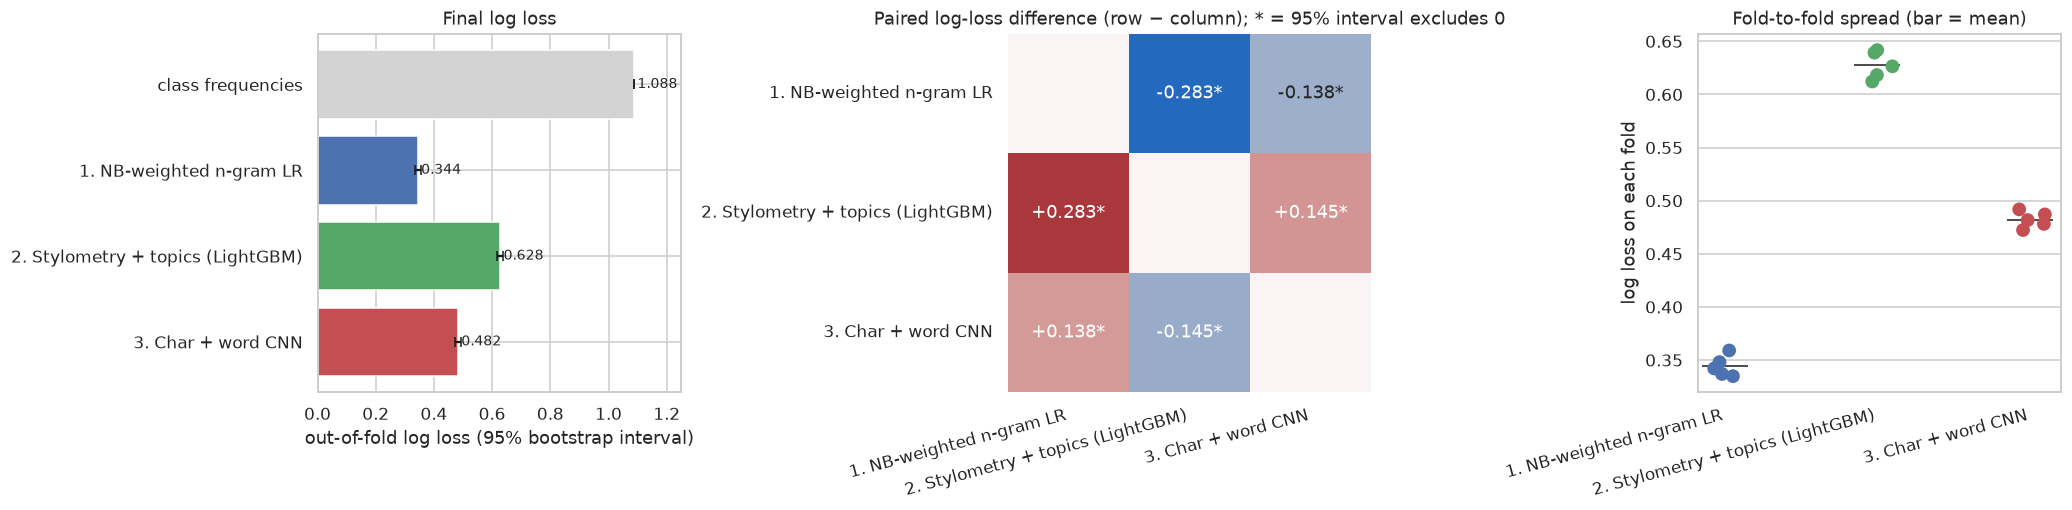

In [2]:
ks = list(M); names = [M[k] for k in ks]; pm = np.zeros((3, 3)); pl = np.zeros((3, 3)); ph = np.zeros((3, 3))
for i, a in enumerate(ks):
    for j, b in enumerate(ks):
        if i != j: d, (lo, hi), _ = S.paired_bootstrap_logloss(y, P[a], P[b]); pm[i, j], pl[i, j], ph[i, j] = d, lo, hi
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
axes[0].barh(names[::-1] + ["class frequencies"], [E[k]["log_loss"] for k in ks][::-1] + [ev_prior["log_loss"]], xerr=[[E[k]["log_loss"] - E[k]["log_loss_ci95"][0] for k in ks][::-1] + [0], [E[k]["log_loss_ci95"][1] - E[k]["log_loss"] for k in ks][::-1] + [0]], color=[COL[k] for k in ks][::-1] + ["lightgrey"], capsize=3)
for i, v in enumerate([E[k]["log_loss"] for k in ks][::-1] + [ev_prior["log_loss"]]): axes[0].text(v + 0.012, i, f"{v:.3f}", va="center", fontsize=9)
axes[0].set_xlabel("out-of-fold log loss (95% bootstrap interval)"); axes[0].set_title("Final log loss"); axes[0].set_xlim(0, 1.25)
lab = np.where(np.eye(3, dtype=bool), "", np.vectorize(lambda d, s: f"{d:+.3f}{'*' if s else ''}")(pm, (pl > 0) | (ph < 0))); sns.heatmap(pd.DataFrame(pm, index=names, columns=names), annot=lab, fmt="", cmap="vlag", center=0, ax=axes[1], cbar=False)
axes[1].set_title("Paired log-loss difference (row − column); * = 95% interval excludes 0"); plt.setp(axes[1].get_xticklabels(), rotation=15, ha="right")
fl = pd.DataFrame({M[k]: E[k]["fold_log_loss"] for k in ks}); sns.stripplot(data=fl, ax=axes[2], size=9, palette=[COL[k] for k in ks]); axes[2].plot(range(3), fl.mean(), "k_", ms=30); axes[2].set_ylabel("log loss on each fold"); axes[2].set_title("Fold-to-fold spread (bar = mean)"); plt.setp(axes[2].get_xticklabels(), rotation=15, ha="right")
plt.tight_layout(); plt.savefig("assets/cmp_01_final_metrics.png", bbox_inches="tight"); plt.show()

## 2. Where each methodology wins and fails

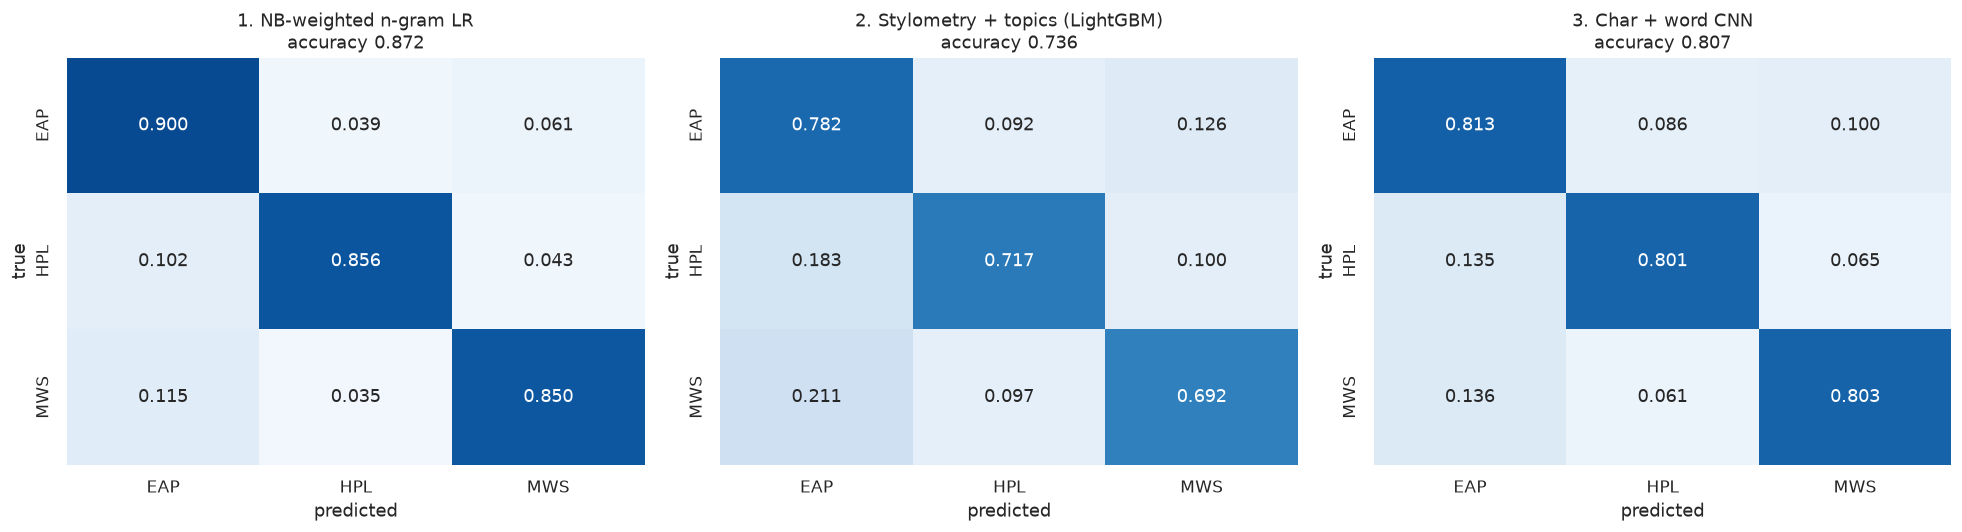

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, k in zip(axes, ks): sns.heatmap(confusion_matrix(y, P[k].argmax(1), normalize="true"), annot=True, fmt=".3f", cmap="Blues", ax=ax, cbar=False, xticklabels=AU, yticklabels=AU, vmin=0, vmax=1); ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"{M[k]}\naccuracy {E[k]['accuracy']:.3f}")
plt.tight_layout(); plt.savefig("assets/cmp_02_confusion_matrices.png", bbox_inches="tight"); plt.show()

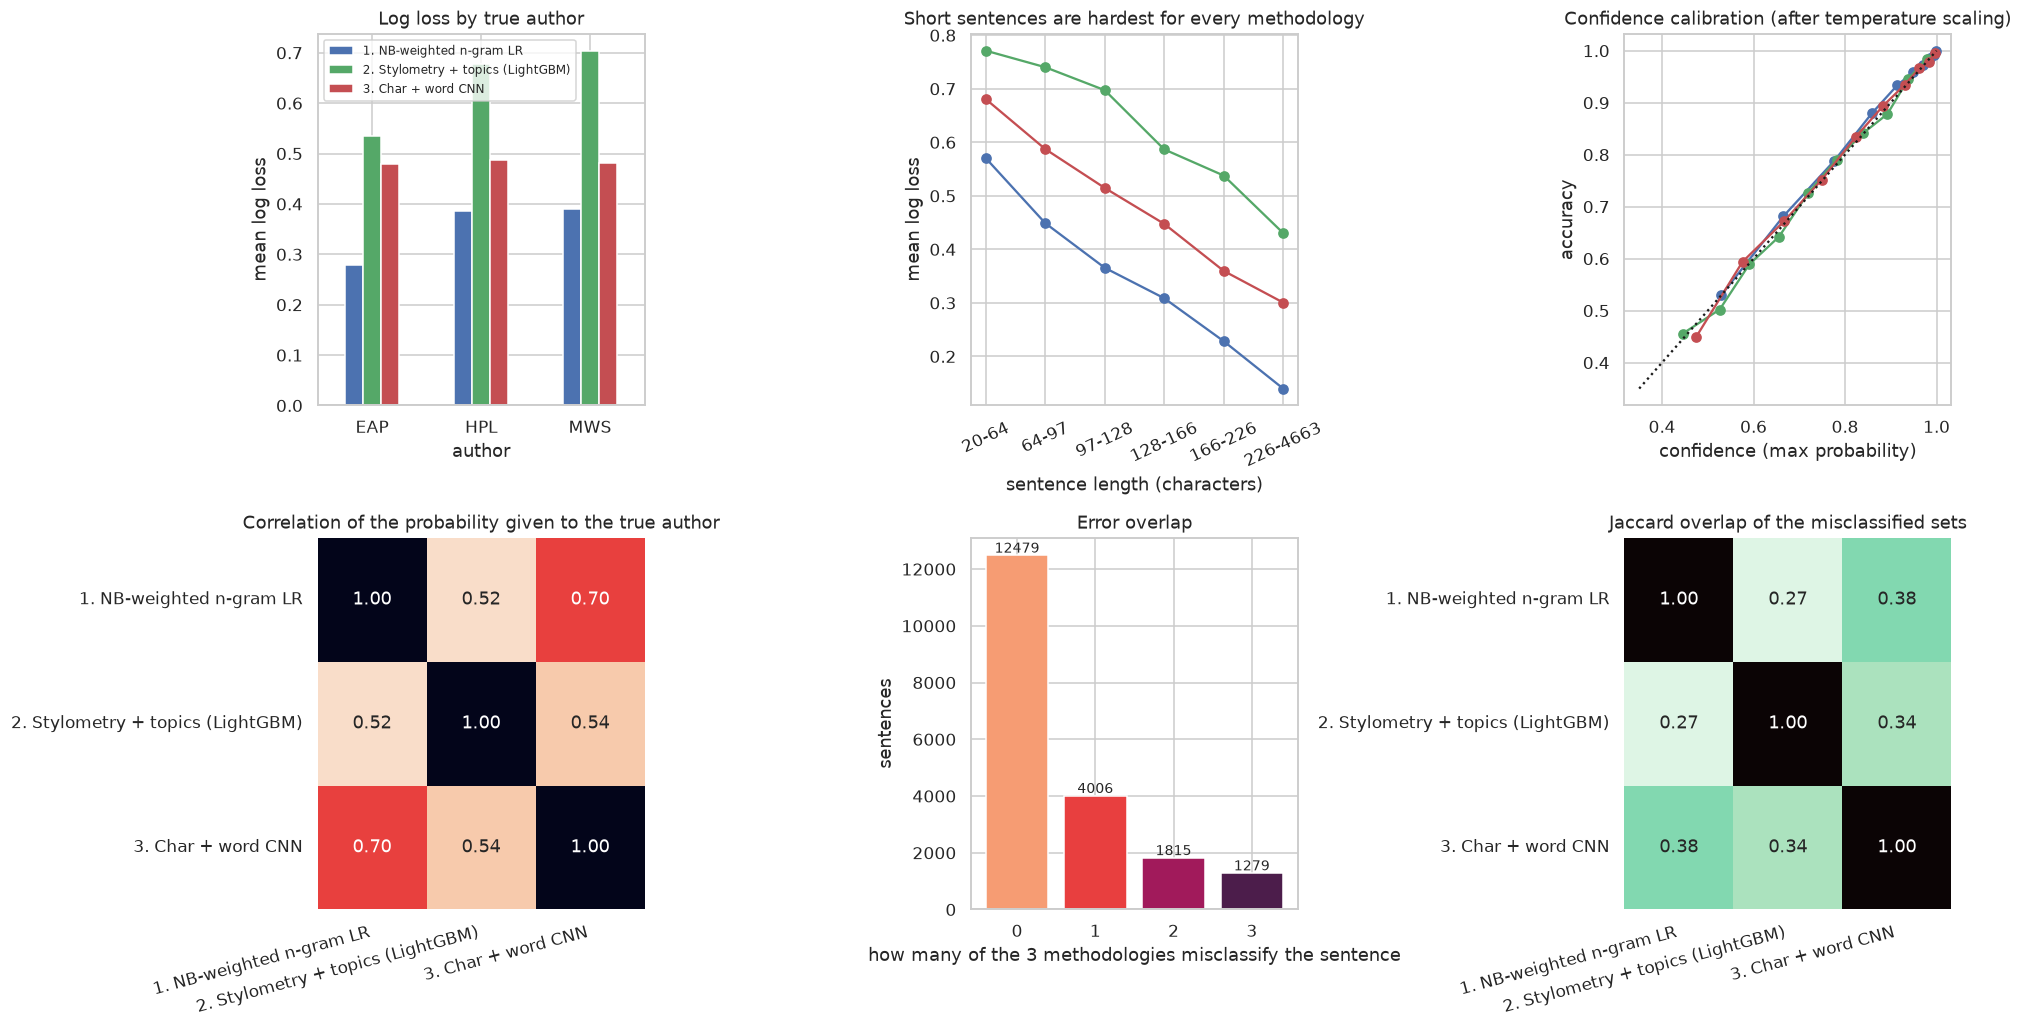

sentences every methodology gets right: 63.7%; at least one gets right (oracle): 93.5%; all three wrong: 6.5%


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9.5)); ok = np.stack([P[k].argmax(1) == y for k in ks], 1); n_ok = ok.sum(1)
nll = pd.DataFrame({M[k]: S.sample_loss(y, P[k]) for k in ks}); nll["author"] = train.author.values; pa = nll.groupby("author").mean().loc[AU]; pa.plot.bar(ax=axes[0, 0], color=[COL[k] for k in ks], rot=0); axes[0, 0].set_ylabel("mean log loss"); axes[0, 0].set_title("Log loss by true author"); axes[0, 0].legend(fontsize=8)
L = train.text.str.len(); bins = pd.qcut(L, 6); ll = pd.DataFrame({M[k]: S.sample_loss(y, P[k]) for k in ks}).groupby(bins, observed=True).mean()
for k in ks: axes[0, 1].plot(range(6), ll[M[k]].values, "o-", color=COL[k], label=M[k])
axes[0, 1].set_xticks(range(6), [f"{int(i.left)}-{int(i.right)}" for i in ll.index], rotation=25); axes[0, 1].set_xlabel("sentence length (characters)"); axes[0, 1].set_ylabel("mean log loss"); axes[0, 1].set_title("Short sentences are hardest for every methodology")
for k in ks:
    for c, a in zip(range(3), AU):
        if c == 0: fp, mp = calibration_curve(np.ones(len(y)) * 0 + (P[k].argmax(1) == y), P[k].max(1), n_bins=10, strategy="quantile"); axes[0, 2].plot(mp, fp, "o-", color=COL[k], label=M[k])
axes[0, 2].plot([0.35, 1], [0.35, 1], "k:"); axes[0, 2].set_xlabel("confidence (max probability)"); axes[0, 2].set_ylabel("accuracy"); axes[0, 2].set_title("Confidence calibration (after temperature scaling)")
corr = pd.DataFrame({M[k]: P[k][np.arange(len(y)), y] for k in ks}).corr(); sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket_r", ax=axes[1, 0], cbar=False, vmin=0.5, vmax=1); axes[1, 0].set_title("Correlation of the probability given to the true author"); plt.setp(axes[1, 0].get_xticklabels(), rotation=15, ha="right")
cnt = pd.Series(3 - n_ok).value_counts().sort_index(); axes[1, 1].bar(cnt.index, cnt.values, color=sns.color_palette("rocket_r", len(cnt))); axes[1, 1].set_xlabel("how many of the 3 methodologies misclassify the sentence"); axes[1, 1].set_ylabel("sentences"); axes[1, 1].set_title("Error overlap")
for x, v in zip(cnt.index, cnt.values): axes[1, 1].text(x, v + 100, str(v), ha="center", fontsize=9)
sns.heatmap(pd.DataFrame([[(~ok[:, i] & ~ok[:, j]).sum() / max((~ok[:, i] | ~ok[:, j]).sum(), 1) for j in range(3)] for i in range(3)], index=names, columns=names), annot=True, fmt=".2f", cmap="mako_r", ax=axes[1, 2], cbar=False); axes[1, 2].set_title("Jaccard overlap of the misclassified sets"); plt.setp(axes[1, 2].get_xticklabels(), rotation=15, ha="right")
plt.tight_layout(); plt.savefig("assets/cmp_03_diagnostics.png", bbox_inches="tight"); plt.show()
print(f"sentences every methodology gets right: {(n_ok == 3).mean():.1%}; at least one gets right (oracle): {(n_ok > 0).mean():.1%}; all three wrong: {(n_ok == 0).mean():.1%}")

## 3. Submission files

One file per methodology in the competition format (`id,EAP,HPL,MWS`), using the temperature-scaled, fold-averaged test probabilities. They are written here but **not submitted**.

In [5]:
os.makedirs("submissions", exist_ok=True); sample = pd.read_csv("data/sample_submission.csv"); assert (sample.id.values == test.id.values).all() and list(sample.columns[1:]) == AU
for k in ks:
    sub = pd.DataFrame(S.clip_norm(T[k]), columns=AU); sub.insert(0, "id", test.id.values); sub.to_csv(f"submissions/submission_{k}.csv", index=False)
    print(k, sub.shape, "mean predicted class shares:", sub[AU].mean().round(3).to_dict(), "| row sums OK:", bool(np.allclose(sub[AU].sum(1), 1)))
summary = dict(metric="multiclass log loss on out-of-fold predictions (5 stratified folds); lower is better", reference_class_frequencies=ev_prior["log_loss"],
               methodologies={M[k]: dict(log_loss=E[k]["log_loss"], log_loss_ci95=E[k]["log_loss_ci95"], accuracy=E[k]["accuracy"], macro_f1=E[k]["macro_f1"], f1_per_author=E[k]["f1_per_author"], fold_log_loss=E[k]["fold_log_loss"]) for k in ks},
               paired_log_loss_difference={f"{M[a]} minus {M[b]}": dict(diff=float(pm[i, j]), ci95=[float(pl[i, j]), float(ph[i, j])]) for i, a in enumerate(ks) for j, b in enumerate(ks) if i != j})
json.dump(summary, open("results/comparison_summary.json", "w"), indent=2)

nblr (8392, 4) mean predicted class shares: {'EAP': 0.416, 'HPL': 0.276, 'MWS': 0.307} | row sums OK: True
style_gbdt (8392, 4) mean predicted class shares: {'EAP': 0.407, 'HPL': 0.283, 'MWS': 0.31} | row sums OK: True
cnn (8392, 4) mean predicted class shares: {'EAP': 0.385, 'HPL': 0.294, 'MWS': 0.321} | row sums OK: True


/tmp/ipykernel_239638/1340350256.py:4: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  print(k, sub.shape, "mean predicted class shares:", sub[AU].mean().round(3).to_dict(), "| row sums OK:", bool(np.allclose(sub[AU].sum(1), 1)))
/tmp/ipykernel_239638/1340350256.py:4: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  print(k, sub.shape, "mean predicted class shares:", sub[AU].mean().round(3).to_dict(), "| row sums OK:", bool(np.allclose(sub[AU].sum(1), 1)))
/tmp/ipykernel_239638/1340350256.py:4: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  print(k, sub.shape, "mean predicted class shares:", sub[AU].mean().round(3).to_dict(), "| row sums OK:", bool(np.allclose(sub[AU].sum(1), 1)))
